In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, chisquare, shapiro
from sklearn.utils import resample

## load data

In [2]:
#Raw df without manipulation, required for the Optuna
raw_df = pd.read_csv('(...)/PDRA_Processed_Data_OS.csv') #change this path for the path of the desired dataset
#Make df: the dataset that will be used for the model
df = raw_df.copy()
#drop irrelevant driver performance features. Change this according to the desired analysis.
df = df.drop(['crash', 'minTTC', 'totalGlanceTimeOther', 'TTC'], axis = 1)
df


,subNumber,Gender,driverTraining,eventNumber,Age,drivingExperience,reactionTime,AVR,attenD,euclideanGazeDispersion,gazeEntropy,yawGazeDispersion,pitchGazeDispersion,totalGlanceTimeDriverMirror,totalGlanceTimeInstrumentCluster,totalGlanceTimeOffRoad,totalGlanceTimeOnRoad,totalGlanceTimePassengerMirror,totalGlanceTimeRearMirror
0,3,1,0,0,37,12,2.75,1.24,0.00,0.13,0.50,0.22,0.19,0.000000,0.000000,0.000000,6.499910,0.0,0.0
1,4,1,0,0,27,9,2.57,2.19,3.00,0.01,2.60,0.12,0.09,0.000000,0.000000,3.000092,3.499991,0.0,0.0
2,4,1,0,1,27,9,1.90,2.19,0.00,0.01,2.15,0.14,0.06,0.000000,0.000000,2.976755,3.520544,0.0,0.0
3,4,1,0,2,27,9,2.63,2.19,0.00,0.03,1.86,0.22,0.15,0.000000,0.000000,3.587340,2.757942,0.0,0.0
4,4,1,0,3,27,9,2.00,2.19,0.00,0.04,1.06,0.29,0.15,0.000000,0.000000,5.784356,0.715487,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,32,1,1,3,25,8,1.62,4.66,2.26,0.06,2.15,0.17,0.19,0.000000,1.846824,3.043648,1.608153,0.0,0.0
101,33,0,1,0,39,18,0.38,1.33,0.00,0.07,2.40,0.22,0.15,0.567236,0.106263,0.000000,5.368379,0.0,0.0
102,33,0,1,1,39,18,1.20,1.33,2.35,0.01,2.53,0.10,0.06,0.000000,0.000000,2.955344,3.544664,0.0,0.0
103,33,0,1,2,39,18,1.13,1.33,0.00,0.14,1.46,0.36,0.22,0.695735,0.000000,5.174656,0.628127,0.0,0.0


In [3]:
#Assign the features that will be used in the model
feature_cols = df.columns[1:].to_list()
target_col = 'reactionTime'
feature_cols.remove ('reactionTime')
X = df [feature_cols]
y = df[target_col]

## create the model

In [4]:
#add intercept constant
X2 = sm.add_constant(X)
model = sm.OLS(y, X2)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           reactionTime   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     3.111
Date:                Wed, 09 Jul 2025   Prob (F-statistic):           0.000271
Time:                        09:47:05   Log-Likelihood:                -53.047
No. Observations:                 105   AIC:                             142.1
Df Residuals:                      87   BIC:                             189.9
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [35]:
#features ranked by p-value.
summary_df = pd.DataFrame({
    'coef': results.params,
    'std_err': results.bse,
    't': results.tvalues,
    'P>|t|': results.pvalues,
    'conf_lower': results.conf_int()[0],
    'conf_higher': results.conf_int()[1]
})

# Separate const and other features
const_row = summary_df.loc[['const']]
features_df = summary_df.drop('const')

# Sort features by p-value ascending
features_df_sorted = features_df.sort_values(by='P>|t|')

# Concatenate const on top
final_df = pd.concat([const_row, features_df_sorted])

# Print the reordered summary table
print(final_df)

                                      coef   std_err         t     P>|t|  \
const                            -4.342125  4.643199 -0.935158  0.352295   
driverTraining                   -0.437865  0.092365 -4.740604  0.000008   
eventNumber                      -0.092978  0.039761 -2.338404  0.021660   
pitchGazeDispersion               2.021248  1.113000  1.816036  0.072809   
yawGazeDispersion                 1.935222  1.096191  1.765406  0.081004   
AVR                               0.022256  0.013187  1.687763  0.095039   
Gender                            0.149963  0.094495  1.587003  0.116140   
euclideanGazeDispersion          -2.204564  1.470637 -1.499054  0.137480   
totalGlanceTimeInstrumentCluster  0.891148  0.712212  1.251239  0.214201   
totalGlanceTimeOnRoad             0.863207  0.713581  1.209683  0.229677   
totalGlanceTimeRearMirror         0.880632  0.777052  1.133299  0.260202   
totalGlanceTimeOffRoad            0.788518  0.709463  1.111429  0.269446   
totalGlanceT

## model evaluation

In [6]:
#use the fitted model to predict the test data
prediction = results.predict (X2)

In [16]:
#simulate residuals
n_simulations = 1000
simulated_residuals = []

for _ in range(n_simulations):
    y_sim = results.predict(X2) + np.random.normal(scale=results.resid.std(), size=len(y))
    model_sim = sm.OLS(y_sim, X2).fit()
    sim_resid = y_sim - model_sim.predict(X2)
    simulated_residuals.append(sim_resid)

simulated_residuals = np.array(simulated_residuals)

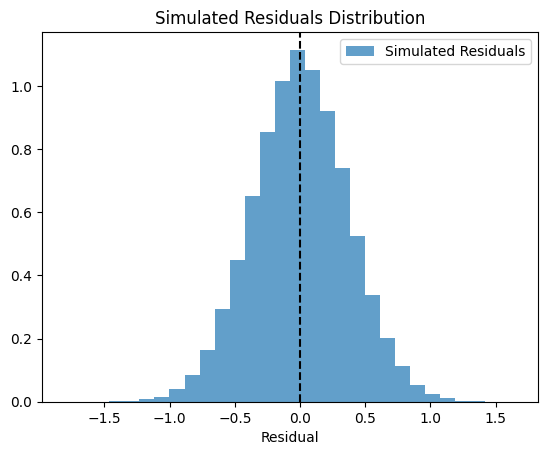

In [17]:
#plot simulated residual distribution
plt.hist(simulated_residuals.flatten(), bins=30, density=True, alpha=0.7, label='Simulated Residuals')
plt.axvline(x=0, color='k', linestyle='--')
plt.title('Simulated Residuals Distribution')
plt.xlabel('Residual')
plt.legend()
plt.show()

In [20]:
#simulated residual uniformity test

# Use standardized residuals
standardized_resid = (results.resid - np.mean(results.resid)) / np.std(results.resid)
uniform_resid = sm.distributions.ECDF(standardized_resid)(standardized_resid)

# Uniformity test (Kolmogorov-Smirnov)
from scipy.stats import kstest
ks_stat, ks_p = kstest(uniform_resid, 'uniform')
print(f"KS test for uniformity: stat={ks_stat:.3f}, p-value={ks_p:.3f}")

KS test for uniformity: stat=0.010, p-value=1.000


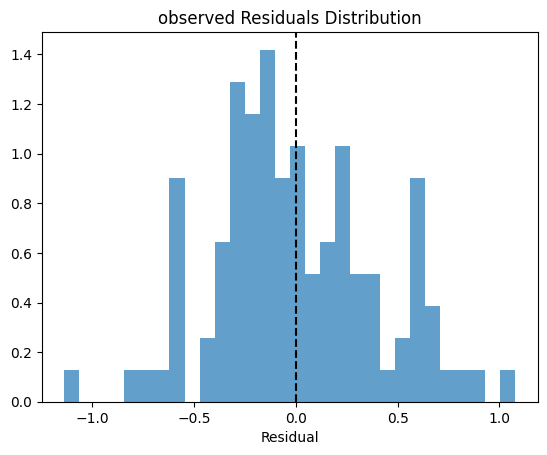

In [31]:
#Observed residual distribution
plt.hist (results.resid, density=True, bins = 30, alpha = 0.7)
plt.axvline(x=0, color='k', linestyle='--')
plt.title('Observed Residuals Distribution')
plt.xlabel('Residual')
plt.show()

In [34]:
#test for standardized observed residuals

# Standardize residuals (important for KS test against standard normal)
standardized_residuals = (results.resid - np.mean(results.resid)) / np.std(results.resid)

#normality ks test
ks_stat, p_value = kstest(standardized_residuals, 'norm')
print(f"KS test for normality: stat={ks_stat:.3f}, p-value={ks_p:.3f}")

KS test for normality: stat=0.075, p-value=1.000


In [21]:
# Variance of actual vs mean simulated residuals
obs_var = np.var(results.resid)
sim_var = np.mean(np.var(simulated_residuals, axis=1))

print(f"Observed Residual Variance: {obs_var:.3f}")
print(f"Simulated Residual Variance: {sim_var:.3f}")

Observed Residual Variance: 0.161
Simulated Residual Variance: 0.134


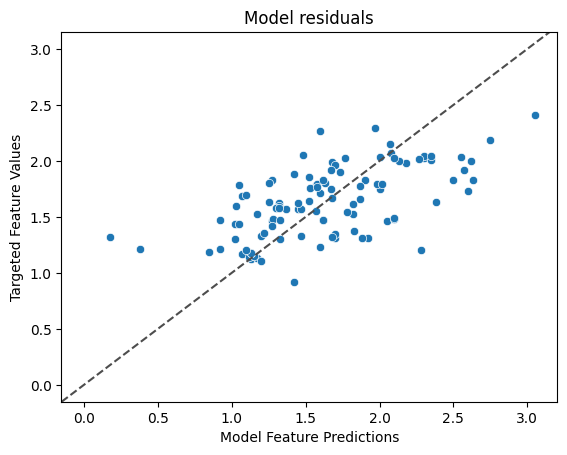

In [13]:
#QQ Plot
f, axs = plt.subplots()
sns.scatterplot (y = prediction, x = df[target_col], ax = axs)
plt.title ("Model residuals")
plt.ylabel ("Targeted Feature Values")
plt.xlabel ("Model Feature Predictions")
plt.axline ([0,0], [3,3], ls="--", c=".3")

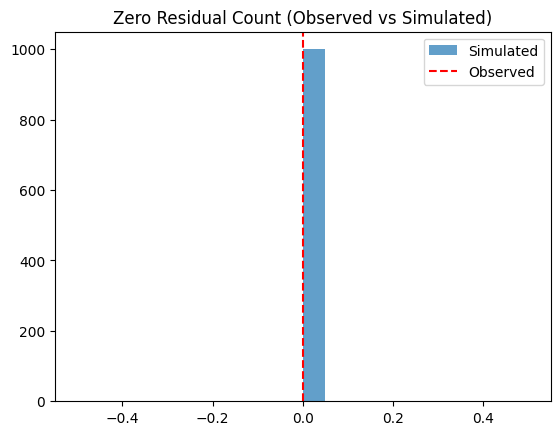

In [22]:
#simulations' residual 0 count plot
num_zeros = np.sum(results.resid == 0)
sim_zeros = [np.sum(sim == 0) for sim in simulated_residuals]

plt.hist(sim_zeros, bins=20, alpha=0.7, label='Simulated')
plt.axvline(x=num_zeros, color='red', linestyle='--', label='Observed')
plt.title("Zero Residual Count (Observed vs Simulated)")
plt.legend()
plt.show()

Text(0.5, 0, 'Targeted Feature Values')

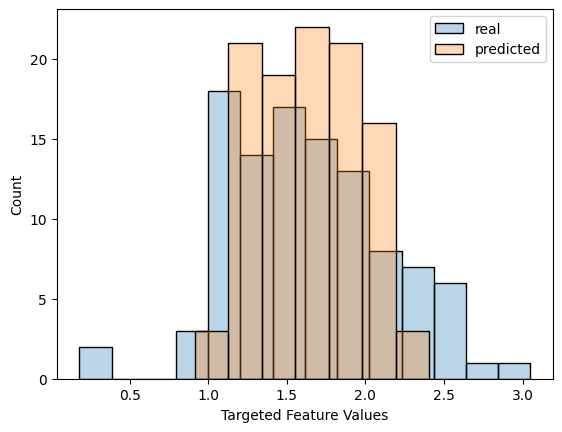

In [23]:
#model prediction comparison with actual data
d,axs = plt.subplots()
sns.histplot (df[target_col], alpha=0.3, label = 'real', ax = axs, binwidth=0.2)
sns.histplot (prediction, alpha=0.3, label = 'predicted', ax=axs, binwidth=0.2)
axs.legend ()
axs.set_xlabel ("Targeted Feature Values")

In [24]:
#model performance metrics
performance_metrics = {
    'RMSE': np.sqrt(mean_squared_error( df[target_col], prediction)),
    'MAE': mean_absolute_error( df[target_col], prediction),
    'R2': r2_score( df[target_col], prediction),
    'MAPE': mean_absolute_percentage_error( df[target_col], prediction),
    'EVS': explained_variance_score( df[target_col], prediction)
}
print (performance_metrics)

{'RMSE': 0.40102682796833544, 'MAE': 0.3206458184544225, 'R2': 0.3780991699074463, 'MAPE': 0.2693001599943547, 'EVS': 0.3780991699074463}


In [25]:
prediction_output = pd.DataFrame (data={'Actual':df[target_col], 'Pred':prediction})

## save the model predictions

In [17]:
#This is the place you save your pickle files for notebook ____

prediction_output.to_pickle ('Predictions_Linear_Regression.pkl')